## Split dataset

In [16]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Transform 
transform = transforms.Compose([
    # transforms.Resize(128,128),
    transforms.ToTensor(),
    transforms.Normalize(mean=[ 0.5,0.5,0.5], std=[0.5, 0.5, 0.5])
])

# Load images
waste_image = datasets.ImageFolder("../dataset-resized", transform=transform)

# Split
train_size = int(0.7* len(waste_image))
test_size = len(waste_image) - train_size
train_data, test_data = random_split(waste_image, [train_size, test_size])

## Data Augmentation

In [17]:
transform_train = transforms.Compose([
    # transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

transform_test = transforms.Compose([
    # transforms.Resize(224,224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

train_data.dataset.transform = transform_train
test_data.dataset.transform = transform_test

## Data Loader

In [18]:
train_loader=DataLoader(train_data, batch_size=32, shuffle=True)
test_loader=DataLoader(test_data, batch_size=32)

## Build CNN

In [19]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = None
        self.num_classes = num_classes
    
    def forward(self, x):
        x=self.conv(x)
        x=x.view(x.size(0), -1)
        if self.fc is None:
            self.fc = nn.Sequential(
                nn.Linear(x.size(1), 128),
                nn.ReLU(),
                nn.Linear(128, self.num_classes)
            )
        return self.fc(x)

## Training

In [20]:
import torch

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam (model.parameters (), lr=0.001)

# Loop
for epoch in range(5):
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad(),
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 1.6945
Epoch 2, Loss: 1.7136
Epoch 3, Loss: 1.3185
Epoch 4, Loss: 1.5972
Epoch 5, Loss: 0.9683


## Validation

In [21]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images,labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Validation Accuracy: {100 * correct/total:.2f}%")

Validation Accuracy: 40.84%


### Matrix Confusion

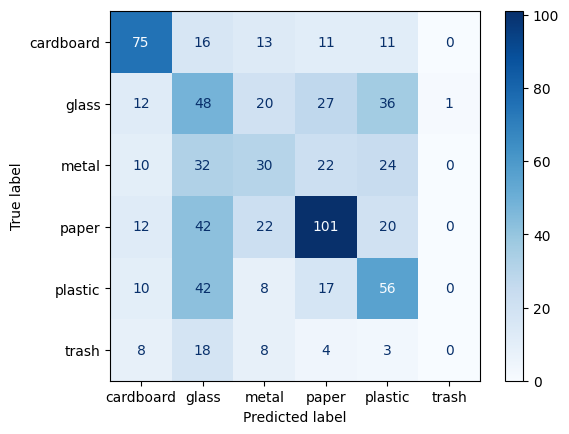

In [22]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Évaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)   # classe prédite
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=waste_image.classes)
disp.plot(cmap=plt.cm.Blues)
plt.show()


### Classification Report

In [23]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=waste_image.classes))


              precision    recall  f1-score   support

   cardboard       0.59      0.60      0.59       126
       glass       0.24      0.33      0.28       144
       metal       0.30      0.25      0.27       118
       paper       0.55      0.51      0.53       197
     plastic       0.37      0.42      0.40       133
       trash       0.00      0.00      0.00        41

    accuracy                           0.41       759
   macro avg       0.34      0.35      0.35       759
weighted avg       0.40      0.41      0.40       759



## Transfer Learning - ResNet

In [26]:
import torchvision.models as models

# Load ResNet18
model = models.resnet18(pretrained=True)

# Adapt
num_classes = len(waste_image.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Train
for epoch in range (5):
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad(),
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 1.1229
Epoch 2, Loss: 0.0600
Epoch 3, Loss: 0.0624
Epoch 4, Loss: 0.2639
Epoch 5, Loss: 0.0156


## 2nd Validation

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm=confusion_matrix(all_labels, all_preds)
print(classification_report(all_labels, all_preds, target_names=waste_image.classes))

              precision    recall  f1-score   support

   cardboard       0.99      0.94      0.96       126
       glass       0.90      0.92      0.91       144
       metal       0.92      0.93      0.92       118
       paper       0.98      0.99      0.98       197
     plastic       0.89      0.89      0.89       133
       trash       0.90      0.88      0.89        41

    accuracy                           0.94       759
   macro avg       0.93      0.92      0.93       759
weighted avg       0.94      0.94      0.94       759



## Inference

In [46]:
from PIL import Image

img = Image.open ("../test_img/trash.jpeg")
img = transform(img).unsqueeze(0)

model.eval()
with torch.no_grad ():
    output = model(img)
    pred = torch.argmax(output, dim=1)

classes=waste_image.classes
print("Prediction :", classes[pred.item()])

Prediction : paper


## Grad-CAM on ResNet18

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torchvision import models

# Hook to capture activations and gradients
gradients = None
activations = None

def save_gradient(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

def save_activation(module, input, ouput):
    global activations
    activations = output

# Last layer of ResNet18
target_layer = model.layer4[1].conv2

target_layer.register_forward_hook(save_activation)
target_layer.register_backward_hook(save_gradient)

# Forward + Backward
img = transform(Image.open("../test_img/trash.jpeg")).unsqueeze(0)
output = model(img)
pred_class = output.argmax(dim=1).item()

# Backprop
model.zero_grad()
class_score = output[0, pred_class]
class_score.backward()

# Calcul Grad-CAM
weights = gradients.mean(dim=(2,3), keepdim=True)
gradcam =(weights * activations).sum(dim=1).squeeze()
gradcam = F.relu(gradcam)

# Normalization
gradcam = gradcam.cpu().detach().numpy()
gradcam = (gradcam - gradcam.min()) / (gradcam.max() - gradcam.min())

# Display
img_np = img.squeeze().permute(1,2,0).cpu().numpy()
plt.imshow(img_np)             
plt.imshow(gradcam, cmap='jet', alpha=0.5) 
plt.title(f"Grad-CAM pour {classes[pred_class]}")
plt.axis('off')
plt.show()


## Back up

In [ ]:
# Savingw weights
torch.save(model.state_dict(), "../models_savior/resnet18_waste.pth")

# Sauvegarde pour déploiement (ONNX)
dummy_input = torch.randn(1, 3, 224, 224)
torch.onnx.export(model, dummy_input, "../models_savior/resnet18_waste.onnx",input_names=["input"], output_names=["output"],dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},opset_version=11)
print("Done")

Done
